<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
# Display dataset shape
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types and non-null information
print("\nDataset information:")
df.info()

# Display summary statistics
print("\nSummary statistics:")
print(df.describe(include="all"))

Dataset shape: (65437, 114)

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWor

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values in each column:")
print(missing_values)

# Handle missing values in important categorical columns
categorical_columns = ["Employment", "JobSat", "RemoteWork"]

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

# Check missing values after handling
print("\nMissing values after handling:")
print(df[categorical_columns].isnull().sum())

Missing values in each column:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Age                               0
Employment                        0
Check                             0
ResponseId                        0
Length: 114, dtype: int64

Missing values after handling:
Employment    0
JobSat        0
RemoteWork    0
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
## Write your code here
# Employment distribution
print("Employment Distribution:")
print(df["Employment"].value_counts(dropna=False))

# Job satisfaction distribution
print("\nJob Satisfaction Distribution:")
print(df["JobSat"].value_counts(dropna=False))

# Professional coding experience distribution
print("\nProfessional Coding Experience Distribution:")
print(df["YearsCodePro"].value_counts(dropna=False))

Employment Distribution:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking fo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


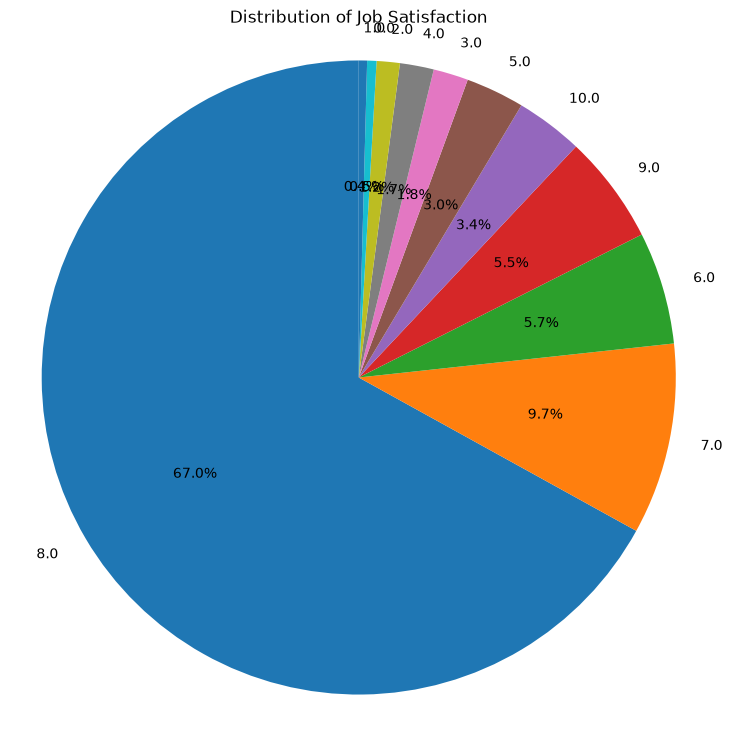

In [6]:
## Write your code here
# Count JobSat values
job_sat_counts = df["JobSat"].value_counts()

# Create pie chart
plt.figure(figsize=(9, 9))

plt.pie(
    job_sat_counts,
    labels=job_sat_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Job Satisfaction")
plt.axis("equal")
plt.show()

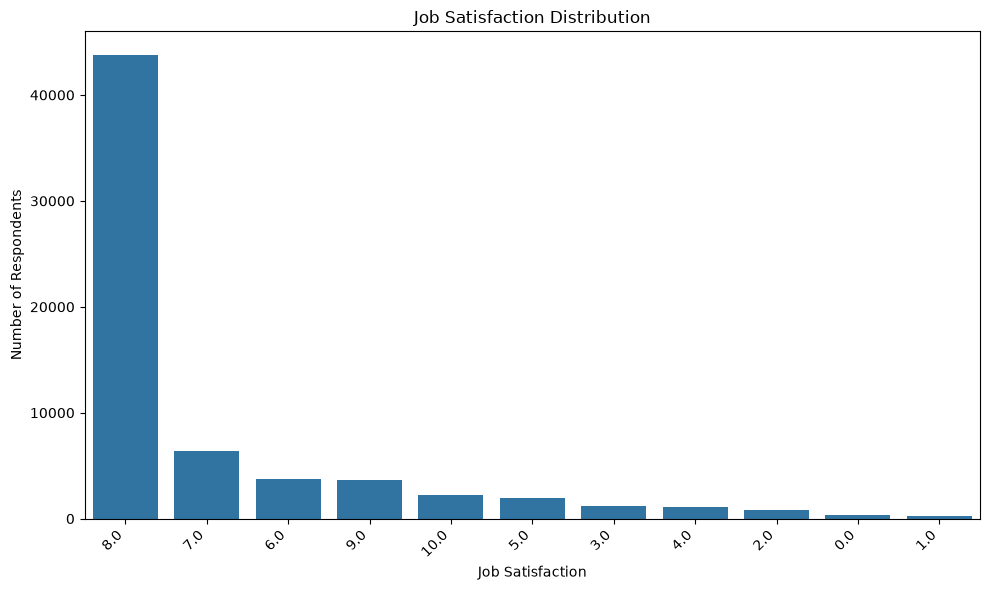

In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="JobSat",
    order=df["JobSat"].value_counts().index
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


Programming Language Comparison:
                         Worked With  Want to Work With
JavaScript                     37492              23774
Python                         30719              25047
SQL                            30682              22400
HTML/CSS                       31816              20721
TypeScript                     23150              20239
Bash/Shell (all shells)        20412              13744
C#                             16318              12921
Java                           18239              10668
Rust                            7559              17232
C++                            13827              10873

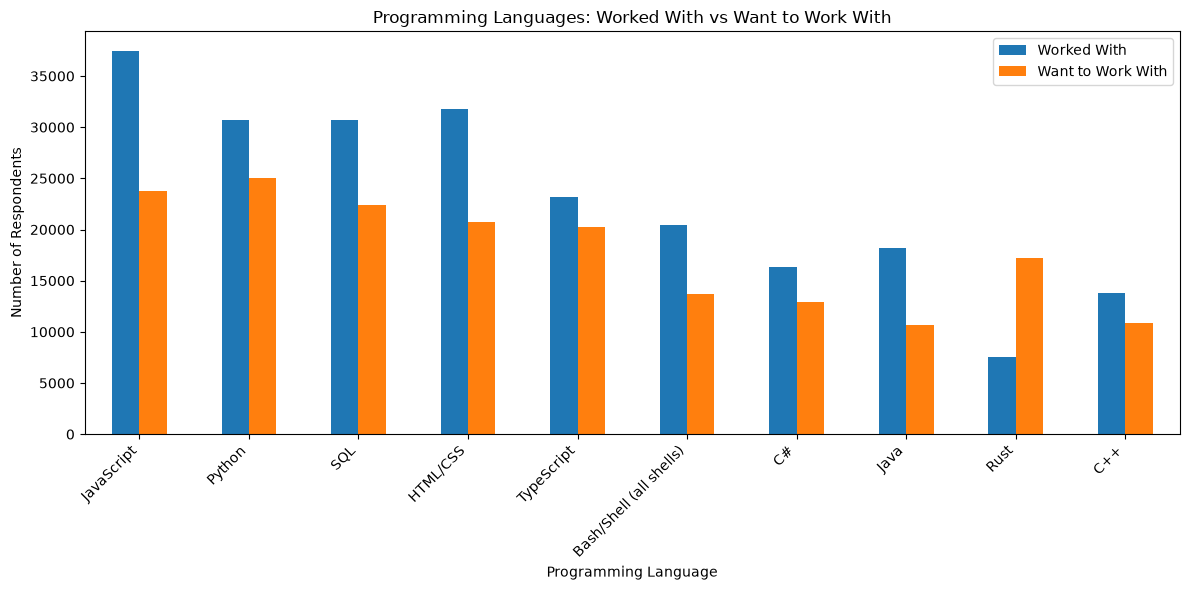

In [8]:
## Write your code here
# Get languages respondents have worked with
worked_languages = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

# Get languages respondents want to work with
wanted_languages = (
    df["LanguageWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

# Count languages
worked_counts = worked_languages.value_counts()
wanted_counts = wanted_languages.value_counts()

# Get top 10 languages from both lists
top_languages = (
    pd.concat([worked_counts, wanted_counts])
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Create comparison DataFrame
language_comparison = pd.DataFrame({
    "Worked With": worked_counts.reindex(top_languages, fill_value=0),
    "Want to Work With": wanted_counts.reindex(top_languages, fill_value=0)
})

print("Programming Language Comparison:")
print(language_comparison)

# Grouped bar chart
language_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Programming Languages: Worked With vs Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


Remote Work by Country:
RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
Brazil                                                                               470   
Canada                                                                               970   
France                                                                              1344   
Germany                                                                             3098   
India                                                                               2290   
Netherlands                                                                         1028   
Poland                                                                               686   
Ukraine                                                                              828   
United Kingdom of Great Britain and Northern Ir...      

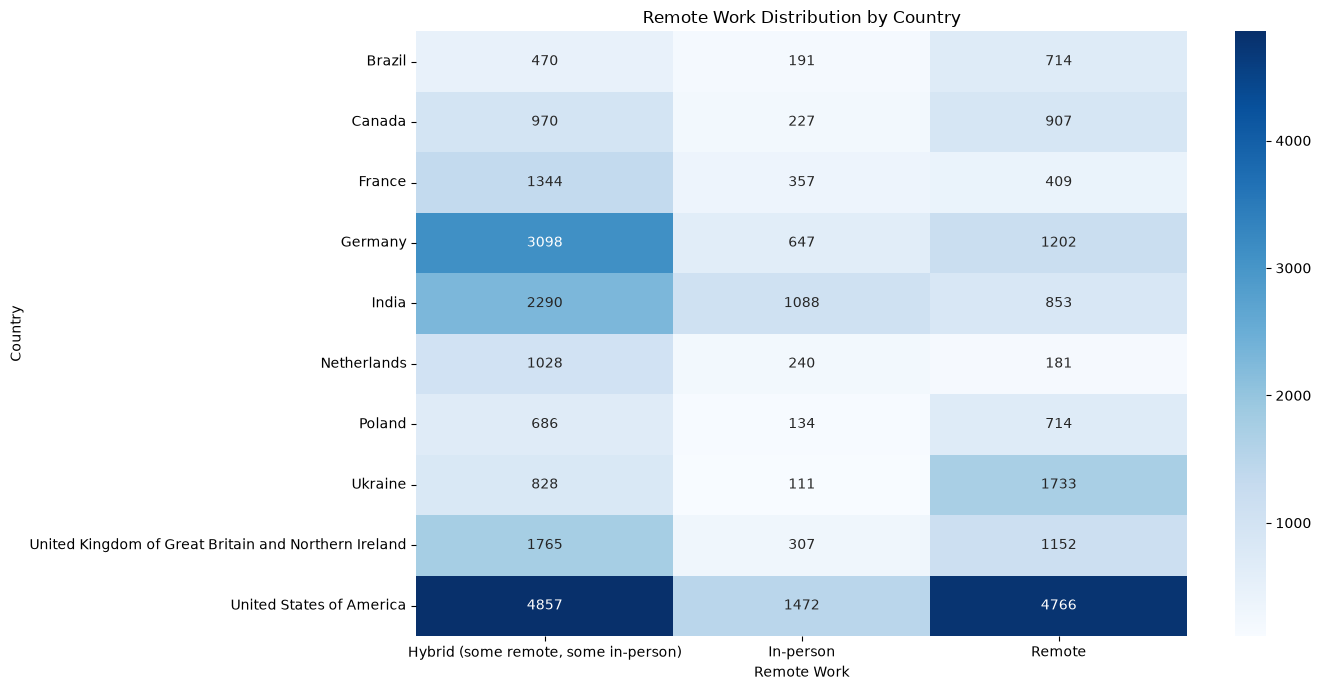

In [9]:
## Write your code here
# Select the top 10 countries
top_countries = df["Country"].value_counts().head(10).index

# Create cross-tabulation
remote_by_country = pd.crosstab(
    df[df["Country"].isin(top_countries)]["Country"],
    df[df["Country"].isin(top_countries)]["RemoteWork"]
)

print("Remote Work by Country:")
print(remote_by_country)

# Create heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    remote_by_country,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Remote Work Distribution by Country")
plt.xlabel("Remote Work")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [10]:
## Write your code here
# Convert YearsCodePro to numeric
years_code_pro = df["YearsCodePro"].replace({
    "Less than 1 year": "0",
    "More than 50 years": "51"
})

df["YearsCodePro_numeric"] = pd.to_numeric(
    years_code_pro,
    errors="coerce"
)

# Check JobSat values
print("JobSat values:")
print(df["JobSat"].unique())

# Try converting JobSat to numeric
job_sat_numeric = pd.to_numeric(
    df["JobSat"],
    errors="coerce"
)

# Create temporary DataFrame for correlation
correlation_data = pd.DataFrame({
    "YearsCodePro": df["YearsCodePro_numeric"],
    "JobSat": job_sat_numeric
}).dropna()

# Calculate Pearson correlation
if len(correlation_data) > 1:
    correlation = correlation_data["YearsCodePro"].corr(
        correlation_data["JobSat"],
        method="pearson"
    )
    print("\nPearson correlation:", correlation)
else:
    print("\nNot enough numeric data to calculate correlation.")

JobSat values:
[ 8.  5. 10.  6.  9.  4.  7.  3.  2.  1.  0.]

Pearson correlation: 0.06394149308751083

Pearson correlation between experience and job satisfaction: -0.028244957301000857

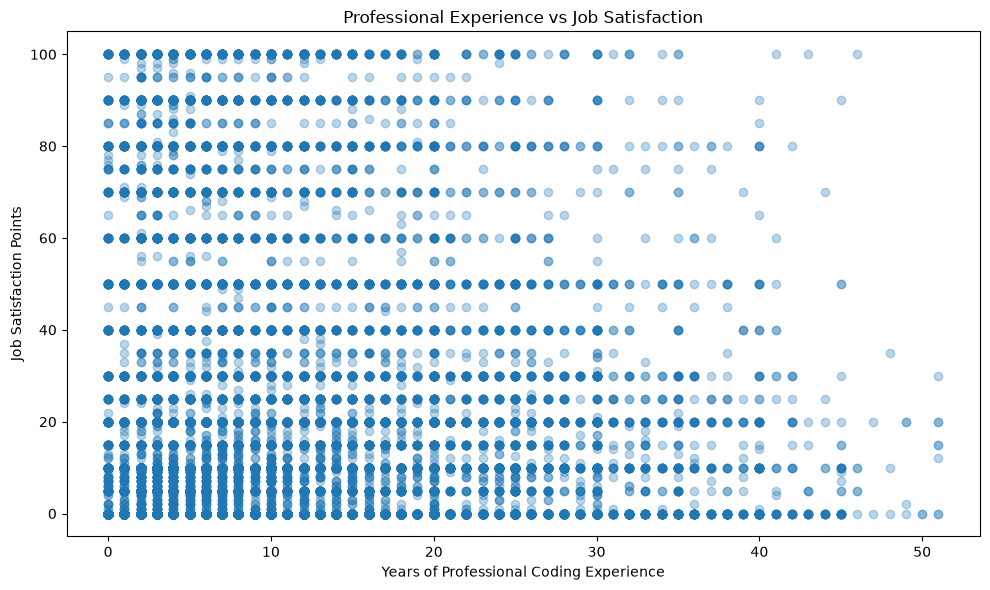

In [11]:
# Convert JobSatPoints_1 to numeric
df["JobSatPoints_1_numeric"] = pd.to_numeric(
    df["JobSatPoints_1"],
    errors="coerce"
)

correlation_data = df[
    ["YearsCodePro_numeric", "JobSatPoints_1_numeric"]
].dropna()

correlation = correlation_data[
    "YearsCodePro_numeric"
].corr(
    correlation_data["JobSatPoints_1_numeric"],
    method="pearson"
)

print("Pearson correlation between experience and job satisfaction:",
      correlation)

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["YearsCodePro_numeric"],
    correlation_data["JobSatPoints_1_numeric"],
    alpha=0.3
)

plt.title("Professional Experience vs Job Satisfaction")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Job Satisfaction Points")
plt.tight_layout()
plt.show()

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Employment vs Education Level:
Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       
Associate degree (A.A., A.S.

/tmp/ipykernel_687/3896770562.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

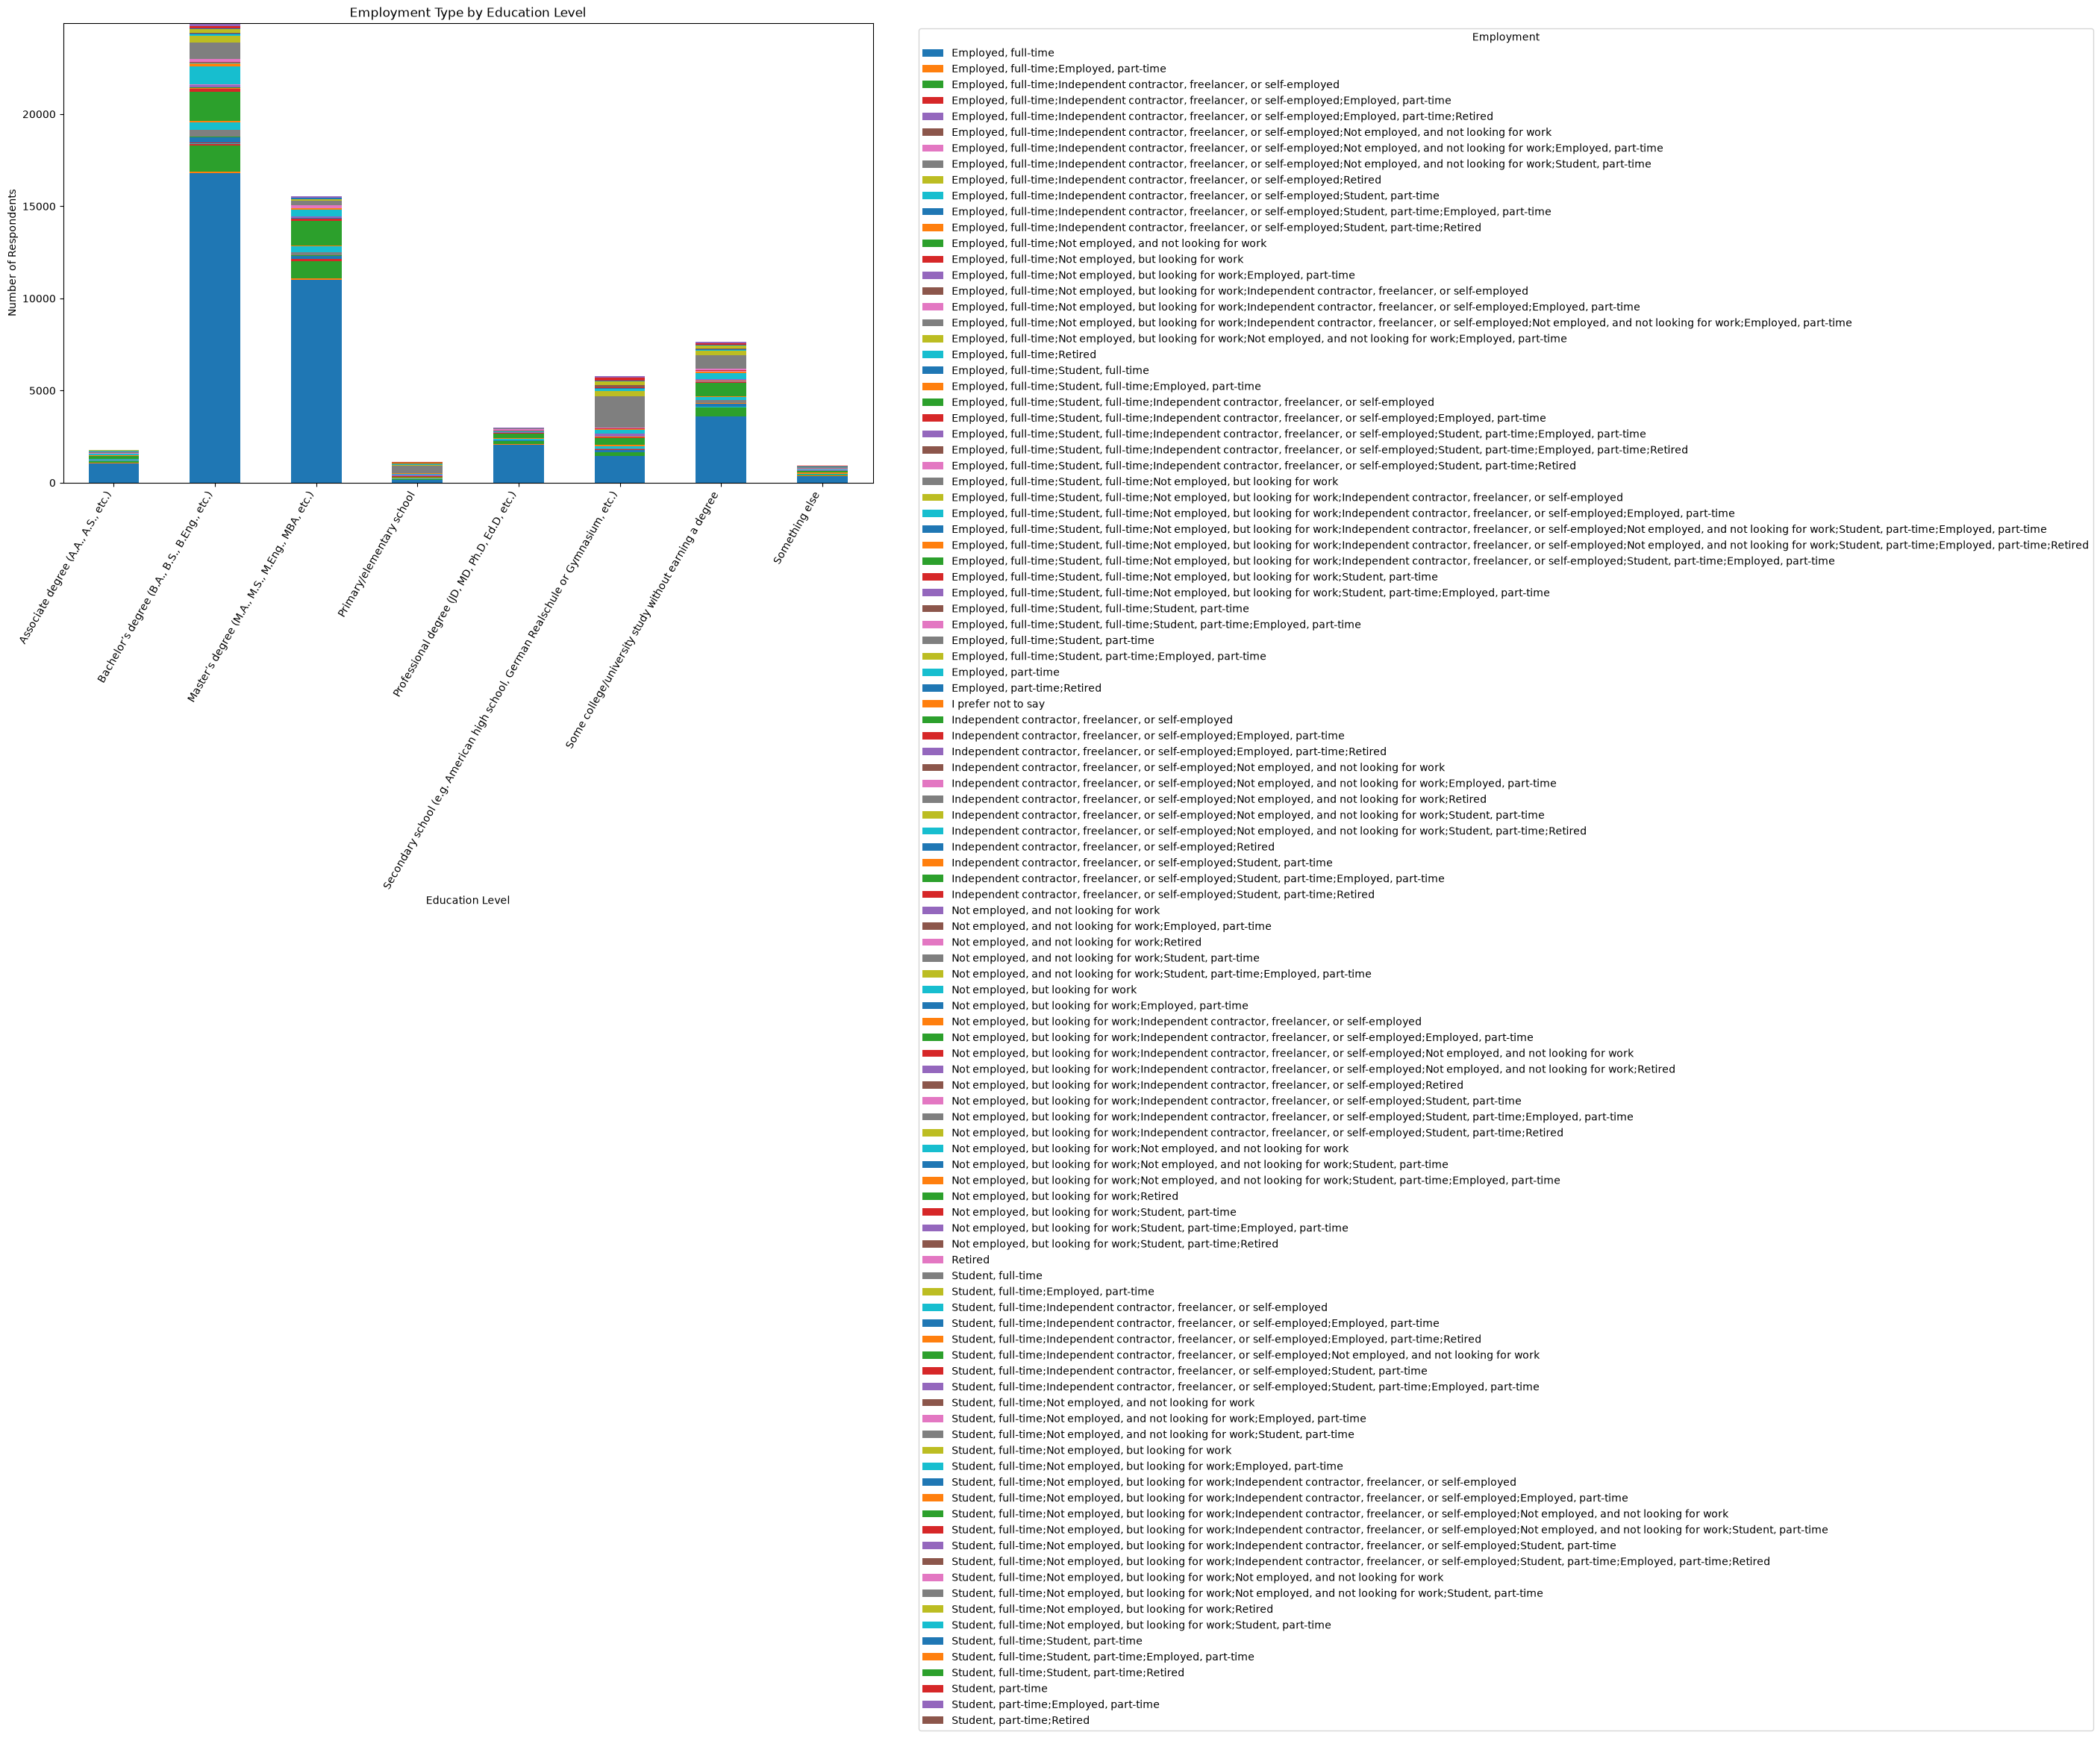

In [12]:
## Write your code here
# Create cross-tabulation
employment_education = pd.crosstab(
    df["EdLevel"],
    df["Employment"]
)

print("Employment vs Education Level:")
print(employment_education)

# Select the top 10 education levels for easier visualization
top_education = df["EdLevel"].value_counts().head(10).index

employment_education_top = employment_education.loc[
    employment_education.index.isin(top_education)
]

# Stacked bar plot
employment_education_top.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

plt.title("Employment Type by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=60, ha="right")
plt.legend(
    title="Employment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [13]:
## Write your code here
# Save the cleaned and analyzed dataset
output_file = "survey-data-cleaned-eda.csv"

df.to_csv(
    output_file,
    index=False
)

print("Cleaned dataset saved successfully as:", output_file)

Cleaned dataset saved successfully as: survey-data-cleaned-eda.csv

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
